In [2]:
import pandas as pd

data = pd.read_csv('Unemployment in India.csv')  # ya pd.read_excel() agar Excel file hai
print(data.head())  # data ke top rows dekhne ke liye

           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3           12285693.0                                     43.97  Rural  
4           12256762.0                                     44.68  Rural  


In [6]:
print(data.columns)

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


In [7]:
data.columns = data.columns.str.strip()

In [8]:
data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)
print(data['Date'].dtype)  # confirm datetime type

datetime64[ns]


In [9]:

print(data['Estimated Unemployment Rate (%)'].describe())

count    740.000000
mean      11.787946
std       10.721298
min        0.000000
25%        4.657500
50%        8.350000
75%       15.887500
max       76.740000
Name: Estimated Unemployment Rate (%), dtype: float64


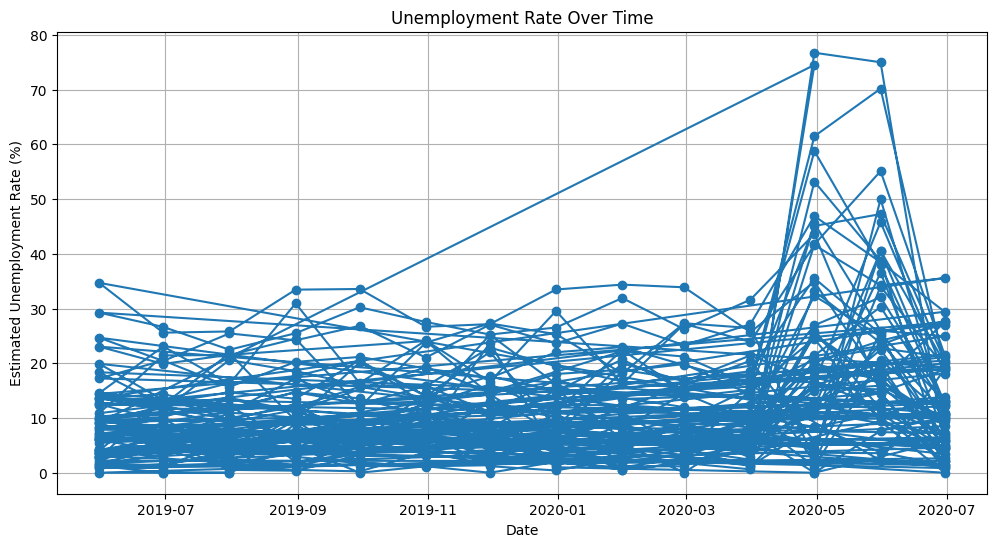

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(data['Date'], data['Estimated Unemployment Rate (%)'], marker='o', linestyle='-')
plt.title('Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.grid(True)
plt.show()

In [11]:
ap_rural = data[(data['Region'] == 'Andhra Pradesh') & (data['Area'] == 'Rural')]

In [12]:
covid_start = pd.to_datetime('2020-03-01')

before_covid = ap_rural[ap_rural['Date'] < covid_start]
after_covid = ap_rural[ap_rural['Date'] >= covid_start]

print("Average Unemployment Rate before Covid:", before_covid['Estimated Unemployment Rate (%)'].mean())
print("Average Unemployment Rate after Covid:", after_covid['Estimated Unemployment Rate (%)'].mean())

Average Unemployment Rate before Covid: 4.170999999999999
Average Unemployment Rate after Covid: 8.915000000000001


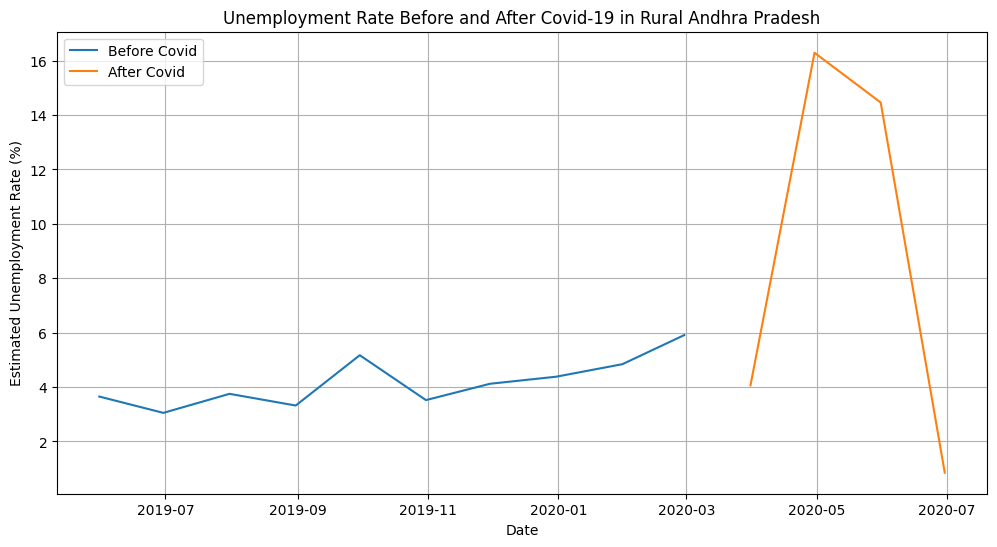

In [13]:
plt.figure(figsize=(12,6))
plt.plot(before_covid['Date'], before_covid['Estimated Unemployment Rate (%)'], label='Before Covid')
plt.plot(after_covid['Date'], after_covid['Estimated Unemployment Rate (%)'], label='After Covid')
plt.title('Unemployment Rate Before and After Covid-19 in Rural Andhra Pradesh')
plt.xlabel('Date')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.legend()
plt.grid(True)
plt.show()

C:\Users\A\AppData\Local\Temp\ipykernel_16504\1099579475.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ap_rural['Month'] = ap_rural['Date'].dt.month


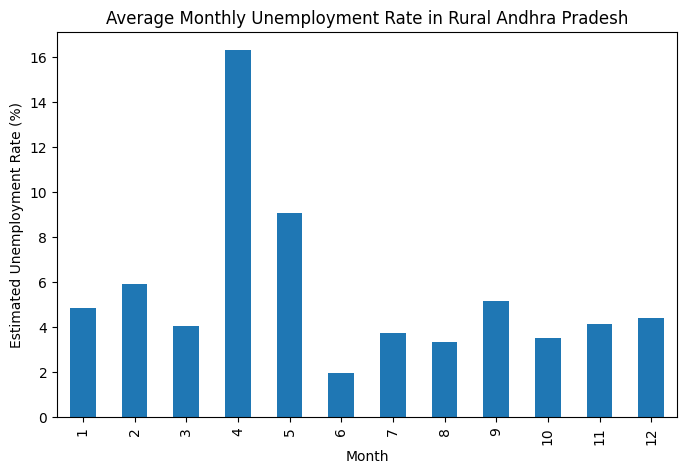

In [14]:
#Seasonal Trends Analyze
ap_rural['Month'] = ap_rural['Date'].dt.month
monthly_avg = ap_rural.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

monthly_avg.plot(kind='bar', figsize=(8,5))
plt.title('Average Monthly Unemployment Rate in Rural Andhra Pradesh')
plt.xlabel('Month')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.show()

In [15]:
#Economic / Social Insights
before_avg = before_covid['Estimated Unemployment Rate (%)'].mean()
after_avg = after_covid['Estimated Unemployment Rate (%)'].mean()

print("Average Unemployment Rate before Covid:", round(before_avg,2))
print("Average Unemployment Rate after Covid:", round(after_avg,2))

Average Unemployment Rate before Covid: 4.17
Average Unemployment Rate after Covid: 8.92


In [16]:
# Filter Urban data
ap_urban = data[(data['Region'] == 'Andhra Pradesh') & (data['Area'] == 'Urban')]

# Average unemployment
rural_avg = ap_rural['Estimated Unemployment Rate (%)'].mean()
urban_avg = ap_urban['Estimated Unemployment Rate (%)'].mean()

print("Average Unemployment Rate in Rural Area:", round(rural_avg,2))
print("Average Unemployment Rate in Urban Area:", round(urban_avg,2))

Average Unemployment Rate in Rural Area: 5.53
Average Unemployment Rate in Urban Area: 9.43
